In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e6_path = kagglehub.competition_download('playground-series-s6e6')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

In [ ]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/train.csv")
df.drop("id",inplace=True,axis=1)
df.sample(4)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
315679,146.626746,35.928960,20.944794,20.736545,20.674327,20.372237,20.202554,2.139835,A/F,Blue_Cloud,QSO
7706,235.586680,45.590151,25.401820,22.604419,21.318157,20.179562,19.355076,0.680161,M,Red_Sequence,GALAXY
500732,209.011027,-1.610848,23.443184,22.255572,20.437742,19.463540,19.266224,0.545533,M,Red_Sequence,GALAXY
44168,221.811747,15.943134,20.146045,18.326015,17.235005,16.676091,16.742263,0.194995,M,Red_Sequence,GALAXY


In [ ]:
df.isnull().mean()*100

alpha                0.0
delta                0.0
u                    0.0
g                    0.0
r                    0.0
i                    0.0
z                    0.0
redshift             0.0
spectral_type        0.0
galaxy_population    0.0
class                0.0
dtype: float64

In [ ]:
df.describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


<Axes: xlabel='i'>

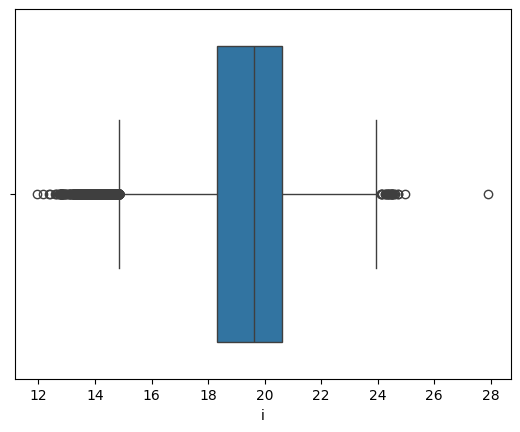

In [ ]:
sns.boxplot(x=df["i"])
# u ,g r i redshift z -keeping data intact

<Axes: xlabel='spectral_type', ylabel='Count'>

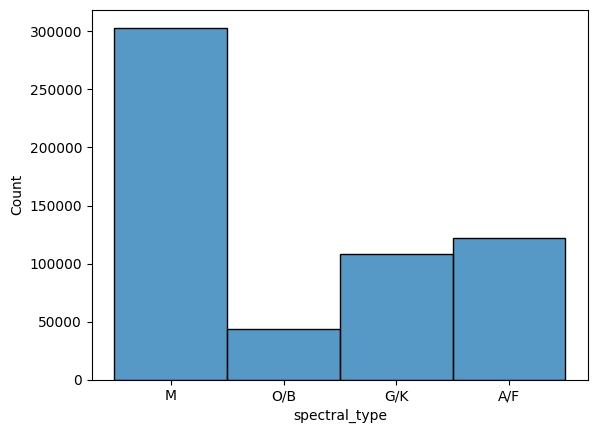

In [ ]:
sns.histplot(df["spectral_type"])

<Axes: xlabel='galaxy_population', ylabel='Count'>

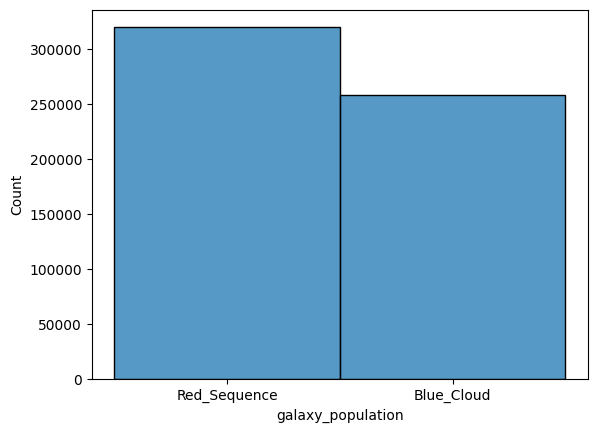

In [ ]:
sns.histplot(df["galaxy_population"])

<Axes: xlabel='class', ylabel='Count'>

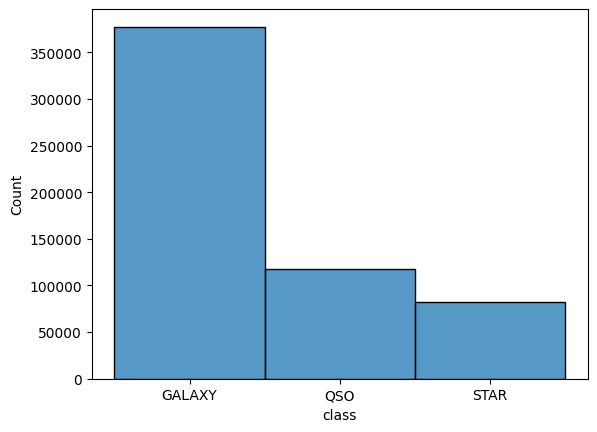

In [ ]:
sns.histplot(df["class"])

<Axes: >

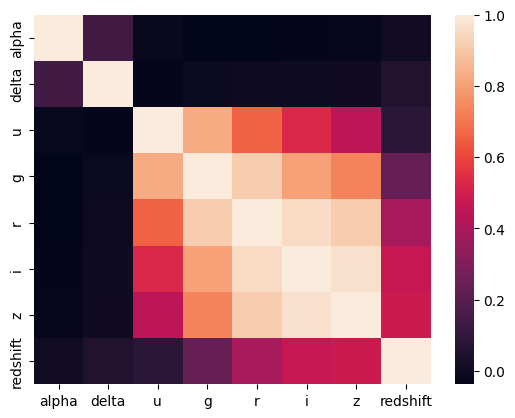

In [ ]:
cols = df.columns[df.dtypes== float]
ohe=df.columns[df.dtypes == object].drop("class")
sns.heatmap(df[cols].corr())

In [ ]:
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.metrics import accuracy_score ,balanced_accuracy_score ,confusion_matrix ,classification_report
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler  , OneHotEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [ ]:
X=df.drop(["class"],axis=1)
y=df["class"]
X_train,X_test,Y_train,Y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)
X_train.shape

(461877, 10)

In [ ]:
trf=ColumnTransformer([("ohe",OneHotEncoder(),ohe)],remainder="passthrough")
le=LabelEncoder()
X_train=trf.fit_transform(X_train)
X_test=trf.transform(X_test)
Y_train=le.fit_transform(Y_train)
Y_test=le.transform(Y_test)

In [ ]:
def objective_xg(trial):
    params={"n_estimators":trial.suggest_int("n_estimators",100,400),
            "lambda": trial.suggest_float('lambda', 1e-8, 1.0, log=True),
            "alpha": trial.suggest_float('alpha', 1e-8, 1.0, log=True),
            "gamma": trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'eta': trial.suggest_float('eta', 0.01, 0.3),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.4, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0)}

    model=XGBClassifier(**params ,random_state=42,n_jobs=-1)
    score=np.mean(cross_val_score(model,X_train,Y_train,cv=3,n_jobs=-1,scoring="accuracy"))
    return score

study_xg=optuna.create_study(direction="maximize")
study_xg.optimize(objective_xg,n_trials=10)
print(study_xg.best_params)

print("="*15)
xgb=XGBClassifier(**study_xg.best_params,random_state=42,n_jobs=-1)
xgb.fit(X_train,Y_train)
y_pred=xgb.predict(X_test)
print("accuracy score : " ,accuracy_score(Y_test,y_pred))
print("balanced accuracy : ",balanced_accuracy_score(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[I 2026-08-16 10:51:45,092] A new study created in memory with name: no-name-2a213cd8-1756-4f5b-8b2e-00e458965089
[I 2026-08-16 10:52:34,834] Trial 0 finished with value: 0.9649365523721684 and parameters: {'n_estimators': 309, 'lambda': 0.05162789046798559, 'alpha': 0.0031737647490496326, 'gamma': 2.9441512466658374e-05, 'eta': 0.21518058840020685, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.5876264342549984, 'colsample_bytree': 0.6790356611336783}. Best is trial 0 with value: 0.9649365523721684.
[I 2026-08-16 10:53:26,987] Trial 1 finished with value: 0.954641603717007 and parameters: {'n_estimators': 170, 'lambda': 0.013752322306101985, 'alpha': 0.9044977326831747, 'gamma': 3.8050926570924265e-05, 'eta': 0.012129592438357945, 'max_depth': 9, 'min_child_weight': 1, 'subsample': 0.6900362371727957, 'colsample_bytree': 0.5854508935645468}. Best is trial 0 with value: 0.9649365523721684.
[I 2026-08-16 10:54:01,857] Trial 2 finished with value: 0.9614291250700945 and parameters

{'n_estimators': 384, 'lambda': 1.2641784389341502e-08, 'alpha': 1.4796002074372011e-06, 'gamma': 2.77612858989143e-07, 'eta': 0.13952631324708598, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.7879135132951199, 'colsample_bytree': 0.949487687523866}
accuracy score :  0.9668312115701048
balanced accuracy :  0.9540397202510547
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     75496
           1       0.96      0.96      0.96     23429
           2       0.93      0.92      0.93     16545

    accuracy                           0.97    115470
   macro avg       0.96      0.95      0.96    115470
weighted avg       0.97      0.97      0.97    115470



In [ ]:
# submission
test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/test.csv")
X_test=test.drop("id",axis=1)
X_test=trf.transform(X_test)
Y_pred=xgb.predict(X_test)
Y_pred=le.inverse_transform(Y_pred)

In [ ]:
submission=pd.DataFrame({"id": test["id"] ,"class": Y_pred})
submission.to_csv("submission.csv",index=False)

In [ ]:
submit_df=pd.read_csv("/kaggle/working/submission.csv")
print(submit_df.head(10))
print("="*25)
print("prediction Counts :")
print(submit_df["class"].value_counts())

       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY
prediction Counts :
class
GALAXY    162161
QSO        50010
STAR       35264
Name: count, dtype: int64


In [ ]:
# data intact we dot
# accuracy score :  0.9666147051182126
# balanced accuracy :  0.9538090800954785

In [ ]:
# try with capping oputliers
#accuracy score :  0.965930544730233
# balanced accuracy :  0.9524850644125734

In [ ]:
# try with the droping corilated column (i and z )
# accuracy score :  0.9595565947865247
# balanced accuracy :  0.9440055817091985